In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
df=pd.read_parquet("analytic_output.parquet")

In [20]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'realized_volatility', 'vwap',
       'momentum_signal', 'rolling_spread', 'price_vs_vwap'],
      dtype='object', name='Price')

In [21]:
def create_dashboard(df,output_file="fx_dashboard.html"):
    fig=make_subplots(
        rows=4,cols=1,
        shared_xaxes=True,
        subplot_titles=[
            "EUR/USD Price vs VWAP",
            "Realized Volatility (Annulaised)",
            "Momentum Signal (+1=up, -1=Down)",
            "Spread Proxy (High-Low/Close)"
        ],
        vertical_spacing=0.08,
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['Close'],
            name="EUR/USD Close",
            line=dict(color='#1f4788',width=1.5)
        ),
        row=1,col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['vwap'],
            name='vwap',
            line=dict(color='#ff7700',width=1.5,dash="dash")
        ),
        row=1,col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['realized_volatility'],
            name="realized volatility",
            fill="tozeroy",
            line=dict(color="#d62728"),
            fillcolor="rgba(214,29,40,0.15)"
        ),
        row=2,col=1
    )
    colors=['green' if v>0 else 'red' if v<0 else 'gray' for v in df['momentum_signal']]
    fig.add_trace(
        go.Bar(
            x=df.index,
            y=df['momentum_signal'],
            name="momentum",
            marker_color=colors,
            opacity=0.7
            
        ),
        row=3,col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['rolling_spread']*10000,
            name='Spread (bps)',
            line=dict(color="#9467bd",width=1)
        ),
        row=4, col=1
    )
    fig.update_layout(
        title=dict(
            text="EUR/USD FX Trading Analytics Dashboard",
            font=dict(size=20,color='#1f4788'),
        ),
        height=900,
        template="plotly_white",
        legend=dict(orientation="h",y=1.02),
        hovermode="x unified"
    )

    fig.write_html(output_file)
    return fig

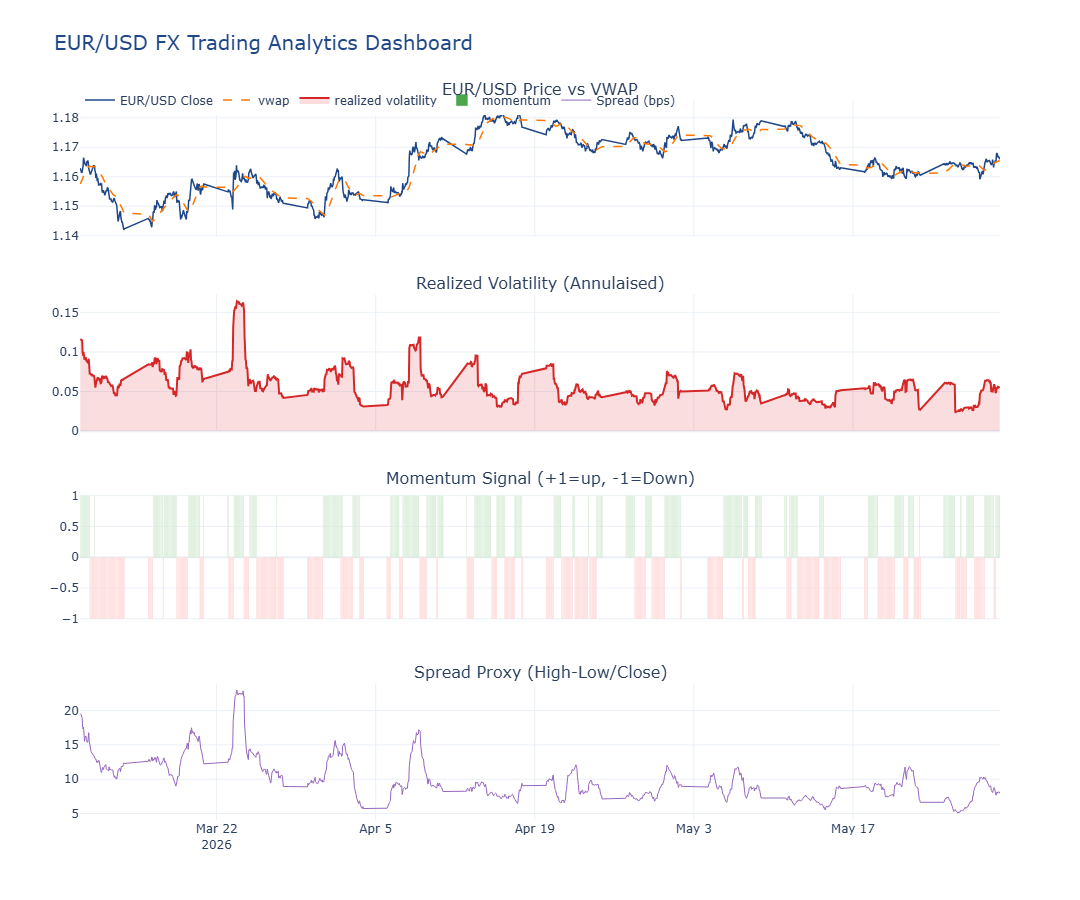

In [22]:
create_dashboard(df)